In [123]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 중고차 가격 예측 데이터셋(Vehicle dataset)
- 중고차의 여러 특징(연식, 주행거리, 연료 타입, 판매자 유형 등)을 바탕으로 중고차 판매 가격(Selling_Price)을 예측하는 회귀(Regression) 모델 구축을 위한 데이터셋입니다

## 2. 컬럼 상세
| 컬럼명 | 데이터 타입 | 의미 및 설명 |
| :--- | :--- | :--- |
| **Car_Name** | String (Object) | 차량 모델 이름 (예: ritz, sx4, ciaz, wagon r, swift, city, brio 등) |
| **Year** | Integer (int64) | 차량 출고 연도 / 연식 (예: 2014, 2017 등) |
| **Selling_Price (타겟)** | Float (float64) | 중고차 현재 판매 가격 (단위: Lakh - 10만 루피) |
| **Present_Price** | Float (float64) | 차량의 신차 출고 당시 가격 (단위: Lakh - 10만 루피) |
| **Kms_Driven** | Integer (int64) | 누적 주행거리 (단위: km) |
| **Fuel_Type** | String (Categorical) | 사용 연료 종류 (Petrol: 가솔린, Diesel: 디젤, CNG: 압축천연가스) |
| **Seller_Type** | String (Categorical) | 판매자 유형 (Dealer: 딜러 매매, Individual: 개인 직거래) |
| **Transmission** | String (Categorical) | 변속기 방식 (Manual: 수동변속기, Automatic: 자동변속기) |
| **Owner** | Integer (int64) | 이전 소유자 수 / 명의 변경 횟수 (0: 첫 번째 소유자, 1: 1회 변경 등) |

[중고차 가격 예측 데이터셋 공식 링크](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?utm_source=gemini) r"C:\kdt_0900_lsu\ml\resource\datasets"
file_name = r"car_data.csv"

file_path = os.path.join(base_path, file_name)

In [124]:
base_path = r"C:\kdt_0900_lsu\ml\resource\datasets"
file_name = r"car_data.csv"

file_path = os.path.join(base_path, file_name)

In [125]:
df = pd.read_csv(file_path)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [126]:
len(df)

301

In [127]:
len(df["Car_Name"].unique())

98

In [128]:
car_df = df.drop("Car_Name", axis=1)
car_df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 1단계 데이터 전처리

In [129]:
# 수치형:
# 분류형:

car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Kms_Driven     301 non-null    int64  
 4   Fuel_Type      301 non-null    object 
 5   Seller_Type    301 non-null    object 
 6   Transmission   301 non-null    object 
 7   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 18.9+ KB


In [65]:
car_df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


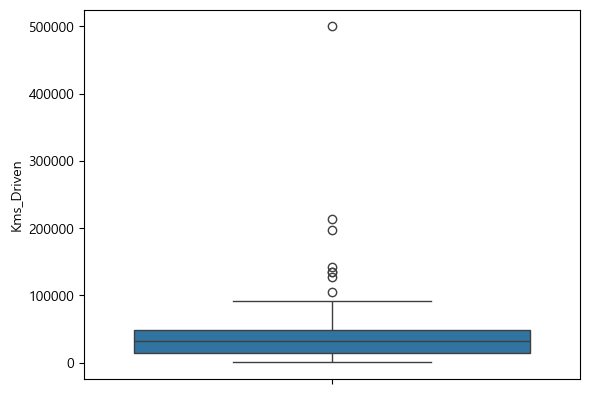

In [66]:
sns.boxplot(car_df, y="Kms_Driven")
plt.show()

In [67]:
car_df = car_df[car_df["Kms_Driven"] < 100000].copy().reset_index(drop=True)
car_df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
288,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
289,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
290,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
291,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


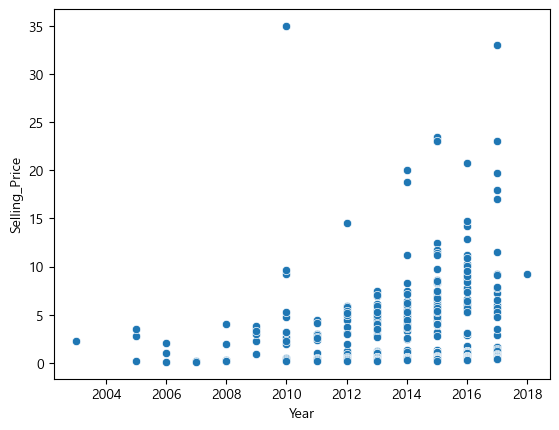

In [68]:
sns.scatterplot(car_df, x="Year", y="Selling_Price")
plt.show()

In [69]:
# 2020년을 기준으로 파생변수 생성
car_df["Vehicle_Age"] = 2020 - car_df["Year"]

In [70]:
car_df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,6
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,7
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,3
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,9
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,6


In [71]:
# vif = [variance_inflation_factor(car_df, value) for i in range(car_df.shape[1])]

In [72]:
car_df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    234
Diesel     57
CNG         2
Name: count, dtype: int64

In [73]:
car_df = car_df[car_df["Fuel_Type"] != "CNG"].copy()
car_df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    234
Diesel     57
Name: count, dtype: int64

In [74]:
# 원핫 인코딩
car_df = pd.get_dummies(car_df, columns=["Fuel_Type", "Seller_Type", "Transmission"], drop_first=True, dtype=int)

In [75]:
car_df

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,6,1,0,1
1,2013,4.75,9.54,43000,0,7,0,0,1
2,2017,7.25,9.85,6900,0,3,1,0,1
3,2011,2.85,4.15,5200,0,9,1,0,1
4,2014,4.60,6.87,42450,0,6,0,0,1
...,...,...,...,...,...,...,...,...,...
288,2016,9.50,11.60,33988,0,4,0,0,1
289,2015,4.00,5.90,60000,0,5,1,0,1
290,2009,3.35,11.00,87934,0,11,1,0,1
291,2017,11.50,12.50,9000,0,3,0,0,1


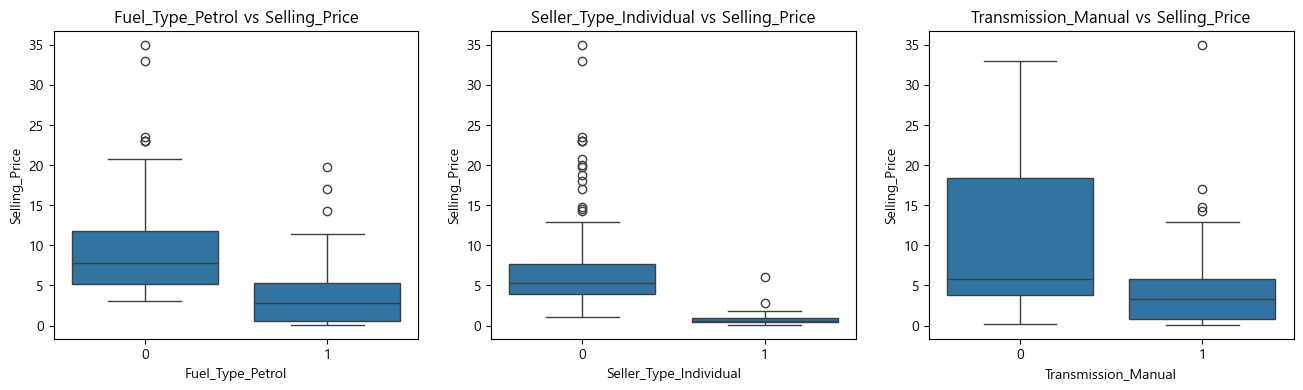

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(ax=axes[0], data=car_df, x="Fuel_Type_Petrol", y="Selling_Price")
axes[0].set_title("Fuel_Type_Petrol vs Selling_Price")
    
sns.boxplot(ax=axes[1], data=car_df, x="Seller_Type_Individual", y="Selling_Price")
axes[1].set_title("Seller_Type_Individual vs Selling_Price")

sns.boxplot(ax=axes[2], data=car_df, x="Transmission_Manual", y="Selling_Price")
axes[2].set_title("Transmission_Manual vs Selling_Price")

plt.show()

In [77]:
car_df.corr()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
Year,1.000000,0.232067,-0.029342,-0.591753,-0.126058,-1.000000,-0.075838,-0.014822,-0.075008
Selling_Price,0.232067,1.000000,0.886872,0.123906,-0.100571,-0.232067,-0.541859,-0.568572,-0.372861
Present_Price,-0.029342,0.886872,1.000000,0.346668,-0.092067,0.029342,-0.459072,-0.542996,-0.316527
Kms_Driven,-0.591753,0.123906,0.346668,1.000000,-0.011859,0.591753,-0.293944,-0.355938,0.017111
Owner,-0.126058,-0.100571,-0.092067,-0.011859,1.000000,0.126058,0.045573,0.100228,0.069753
Vehicle_Age,-1.000000,-0.232067,0.029342,0.591753,0.126058,1.000000,0.075838,0.014822,0.075008
Fuel_Type_Petrol,-0.075838,-0.541859,-0.459072,-0.293944,0.045573,0.075838,1.000000,0.359843,0.083699
Seller_Type_Individual,-0.014822,-0.568572,-0.542996,-0.355938,0.100228,0.014822,0.359843,1.000000,0.092048
Transmission_Manual,-0.075008,-0.372861,-0.316527,0.017111,0.069753,0.075008,0.083699,0.092048,1.000000


In [78]:
correlation_matrix = car_df.corr()

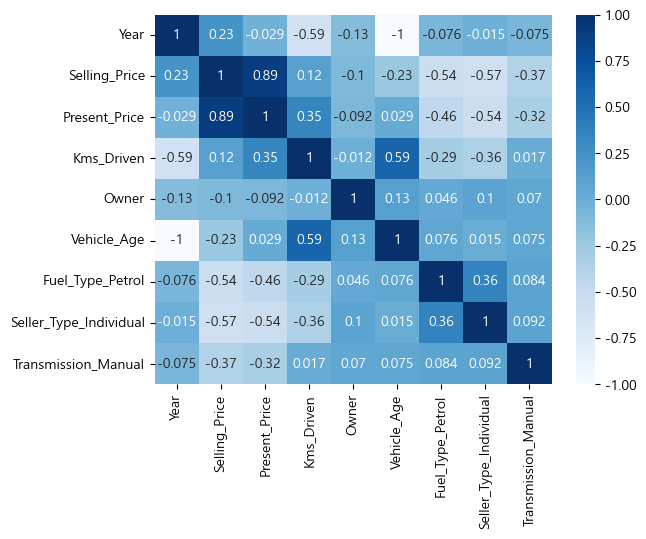

In [79]:
sns.heatmap(correlation_matrix, cmap="Blues", annot=True)
plt.show()

In [80]:
X = car_df.drop("Selling_Price", axis=1)
X.head()

,Year,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,5.59,27000,0,6,1,0,1
1,2013,9.54,43000,0,7,0,0,1
2,2017,9.85,6900,0,3,1,0,1
3,2011,4.15,5200,0,9,1,0,1
4,2014,6.87,42450,0,6,0,0,1


In [81]:
y = car_df["Selling_Price"]
y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [82]:
car_df.drop("Year", axis=1, inplace=True)

In [83]:
car_df.head(1)

,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,1,0,1


In [84]:
X = car_df.drop("Selling_Price", axis=1)
X.head(1)

,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,5.59,27000,0,6,1,0,1


In [85]:
y = car_df["Selling_Price"]
y.head(1)

0    3.35
Name: Selling_Price, dtype: float64

In [86]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif 

[2.143307654921878,
 7.144667275239435,
 1.072065374632327,
 11.410259365211015,
 5.2071970263018175,
 2.2216299186754545,
 5.639754058168289]

## 트리
   - 계층적으로 자료를 표현할 때 적합한 자료구조
   - 데이터를 순차적으로 저장하지 않기 때문에 비선형 자료구조
   - 트리 내에 또 다른 트리가 있는 재귀적 자료구조
   - 하나의 루트 노드와 0개 이상의 하위 트리로 작성됨

### 트리의 사용 예시
   - 계층적 데이터 저장: 파일 및 폴더
   - 효율적인 검색속도: 효율적인 삽입, 삭제, 검색을 위해 사용
   - 데이터 베이스 인덱싱 구현
   - 힙(Heap)

### 트리 용어 정리 
   - 루트(Root)노드 : 트리의 가장 높은 곳에 있는 노드
   - 모든 노드는 루트노드의 서브트리에 속한다
   - 리프(Leaf)노드 : 트리의 가장 하단에 있는 노드
   - 자식노드가 없는 노드
   - 자식(Child)노드 : 동일한 부모를 가진 노드들을 의미함
   - 리프노드가 아닌 자식이 있는 노드 = 내부(Internal)노드, 비 단말(Non-Terminal)노드
   - 형제(Sibling)노드 : 동일한 부모를 가진 노드들을 의미한다
   - 조상(ancestro)노드 :  루트까지 경로상에 있는 모든 노드들의 집합
   - 후손(Descendant)노드 : 노드 아래로 매달린 모든 노드들의 집합
   - 서브트리(Subtree)노드 : 노드 자신과 후손 노드로 구성된 트리
   - 차수(Degree) : 어떤 노드가 가지고 있는 자식의 수
   - 레벨(Level) : 루트에서 얼마나 멀리 떨어져 있는지를 나타내는 것
   - 키(Key) : 탐색에 사용되는 노드에 저장된 정보

<img src="https://i.namu.wiki/i/8pViDtKiYxEmcz1zj2WHZEpLHeu4q4n1bAjOOTvA4rLde3d-miR4lbCeFRjhzuTV1SLW5vFdg81Q6vb6fm1I9Q.webp" style="width:800px;"/>

## 결정 트리(Decision Tree)란?
- 결정 트리는 데이터에 숨겨져 있는 규칙을 컴퓨터가 스스로 찾아내어, 마치 스무고개(IF-ELSE) 게임처럼 나무 가지를 뻗으며 정답을 찾아가는 지도학습(Supervised Learning) 알고리즘입니다.
- 한 줄 결론, 구간의 평균값으로 그 값을 예측하게 만든다.

| 구분 | 결정 트리 분류 (Classifier) | 결정 트리 회귀 (Regressor) |
| :--- | :--- | :--- |
| 목적 | 데이터가 어떤 그룹/카테고리에 속하는지 분류 | 데이터의 연속된 실숫값(수치)을 예측 |
| 예시 | 이 손님이 가방을 `산다(1)` / `안 산다(0)` | 오늘 특정 시간대에 따릉이가 `몇 대` 대여될까? |
| 최종 정답 결정 방식 | 다수결의 원칙<br>(마지막 방에 더 많은 쪽으로 분류) | 평균값 계산<br>(마지막 방에 모인 수치들의 평균을 내어 예측) |

### 2. 작동 원리 (데이터가 분리되는 과정)
1. 뿌리 노드 (Root Node): 전체 데이터가 시작되는 지점입니다.
2. 중간 노드 (Internal Node): 컴퓨터가 불순도를 낮추기 위해 최적의 질문(예: `Hour <= 17`)을 던져 데이터를 두 갈래로 쪼갭니다.
3. 최종 노드 (Leaf Node): 더 이상 쪼개지지 않는 마지막 나뭇잎 방입니다. 
   * 분류: 이 방에 모인 데이터 중 가장 많은 클래스가 최종 정답이 됩니다.
   * 회귀: 이 방에 모인 데이터들의 평균값이 최종 예측 숫자가 됩니다.

### 3. 장점과 단점
* 장점:
  * 시각화했을 때 컴퓨터가 왜 이런 판단을 내렸는지 사람이 눈으로 로직을 완벽히 이해할 수 있습니다. (설명 가능성 높음)
  * 데이터의 스케일링(정규화) 같은 전처리 작업의 영향을 거의 받지 않아 편리합니다.
* 단점:
  * 조건을 무한정 만들게 놔두면 훈련 데이터에만 완벽하게 맞아떨어지는 과적합(Overfitting)에 매우 취약합니다.
  * 해결책: 나무의 최대 깊이를 제한하는 가지치기(pruning) `max_depth` 같은 하이퍼파라미터 조율이 필수적입니다.

![](https://drive.google.com/thumbnail?id=1V1M-BXjutvDlwOhw6bUW-Zlh1J0etHpC&sz=w1000)

### 결정 트리 수행 순서
1. 최적의 특성(feature)과 분할 기준(threshold)을 찾아 첫 번째 분할을 수행
2. 만약 분류라면
   - Gini 불순도(Gini Impurity)
   - 엔트로피(Entropy)

4. 만약 회귀라면
   - 평균 제곱 오차(Mean Squared Error, MSE)
   - 절대 평균 오차(Mean Absolute Error

5. 각 하위 노드에 대해 위 단계를 반복하고 이 과정으로 여러 깊이로 설정합니다
6. 모든 노드가 더이상 나눌 수 없거나 특정 조건을 만족할 떄까지 반복합니다
7. 더 이상 분할이 불가능할 때 리프 노트가 생성됩니다
   - 분류 문제: 가장 많은 클래스가 있는 클래스를 예측값으로 사용
   - 회귀 문제: 평균값을 예측값으로 사용

#### Gini 불순도(Gini Impurity)
- 한 노드에 데이터 순수도(Purity)를 측정하는 지표입니다. 한 노드에 있는 샘플들이 동일한 클래스에 속할 확률이 높을수록 Gini 불순도가 낮아집니다
- 즉 노드가 얼마나 섞여있는지 나타내는 지표입니다.

#### 엔트로피(Entropy)
- 정보의 불확실성(혼란도)를 측정합니다. 엔트로피가 높을 수록 해당 노드에 데이터가 더 섞여있으며 예측하기 어렵습니다.
- 데이터가 균등하게 분포될 때 최대값을 가집니다.

### 예시 데이터프레임 (온도, 습도, 운동량)
- 아래 데이터가 있다고 가정해보자.

| 샘플 번호 | 온도 (°C) | 습도 (%) | 운동량 (Target, 분) |
| :---: | :---: | :---: | :---: |
| #1 | 15 | 40 | **60** |
| #2 | 18 | 45 | **55** |
| #3 | 28 | 75 | **20** |
| #4 | 30 | 80 | **15** |
| #5 | 32 | 85 | **10** |

### 1. 분산을 구한다
* **대상 데이터 (운동량):** `[60, 55, 20, 15, 10]` (총 5개)
* **평균 ($\mu$):** $(60 + 55 + 20 + 15 + 10) / 5 = \mathbf{32}$
* **분산 ($\sigma^2$):** 각 데이터에서 평균(32)을 뺀 뒤 제곱한 값들의 평균
  $$((60-32)^2 + (55-32)^2 + (20-32)^2 + (15-32)^2 + (10-32)^2) / 5$$
  $$= (784 + 529 + 144 + 289 + 484) / 5 = \mathbf{446}$$

- **처음 상태:** 운동량의 평균은 **32**, 분산(오차 위험도)은 **446**인 상태에서 출발합니다.

### 2. 운동량 평균 32에 해당하는 기준으로 중간 값후보에 등록한다.
예를 들어 습도를 골랐다면
* **#2 샘플:** 45%
* **#3 샘플:** 75%
- 45%와 75%의 딱 중간인 **60%** `(45 + 75) / 2` 가 칼날 후보가 된다.

- 왼쪽 그룹: 60보다 작은 그룹(40, 45)
- 오른쪽 그룹: 60보다 큰 그룹(75, 80, 85)

### 3. 왼쪽 그룹과 오른쪽 그룹 각각의 분산을 구한다
#### 1) 왼쪽 그룹 (습도 60% 미만: 40%, 45%)
* **대상 운동량:** `[60, 55]`
* **평균:** $(60 + 55) / 2 = \mathbf{57.5}$
* **분산 식:**
  $$\text{왼쪽 분산} = \frac{(60 - 57.5)^2 + (55 - 57.5)^2}{2}$$
  $$\text{왼쪽 분산} = \frac{(2.5)^2 + (-2.5)^2}{2} = \frac{6.25 + 6.25}{2} = \mathbf{6.25}$$

#### 2) 오른쪽 그룹 (습도 60% 이상: 75%, 80%, 85%)
* **대상 운동량:** `[20, 15, 10]`
* **평균:** $(20 + 15 + 10) / 3 = \mathbf{15}$
* **분산 식:**
  $$\text{오른쪽 분산} = \frac{(20 - 15)^2 + (15 - 15)^2 + (10 - 15)^2}{3}$$
  $$\text{오른쪽 분산} = \frac{(5)^2 + (0)^2 + (-5)^2}{3} = \frac{25 + 0 + 25}{3} = \frac{50}{3} \approx \mathbf{16.67}$$

* **가중 분산 합 공식:**
  $$\text{자식 노드 분산 합} = \left( \frac{\text{왼쪽 데이터 수}}{\text{전체 데이터 수}} \times \text{왼쪽 분산} \right) + \left( \frac{\text{오른쪽 데이터 수}}{\text{전체 데이터 수}} \times \text{오른쪽 분산} \right)$$

* **실제 계산 식:**
  $$\text{자식 노드 분산 합} = \left( \frac{2}{5} \times 6.25 \right) + \left( \frac{3}{5} \times 16.67 \right)$$
  $$\text{자식 노드 분산 합} = 2.5 + 10 = \mathbf{12.5}$$

### 4. 최종 분산 감소량을 구한다

이제 처음에 구했던 부모 노드의 분산(446)에서 방금 구한 자식들의 분산 합(12.5)을 빼서 이 칼날(습도 60%)의 최종 점수를 매깁니다.

$$\text{분산 감소량} = \text{부모 분산} - \text{자식 분산 합}$$
$$\text{분산 감소량} = 446 - 12.5 = \mathbf{433.5}$$

### 5. 모든 컬럼의 값들을 계산하고 최종 분산 감소량이 가장 큰 값들만 선택하여 데이터가 1개가 될 때까지 나눈다.

In [89]:
y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [90]:
car_df.describe()

,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
count,291.000000,291.000000,291.000000,291.000000,291.000000,291.000000,291.000000,291.000000
mean,4.665395,7.452680,32582.728522,0.034364,6.202749,0.804124,0.347079,0.879725
std,5.064562,8.490664,21484.532545,0.182477,2.694207,0.397557,0.476861,0.325843
min,0.100000,0.320000,500.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,0.900000,1.200000,15000.000000,0.000000,4.000000,1.000000,0.000000,1.000000
50%,3.750000,6.100000,31000.000000,0.000000,5.000000,1.000000,0.000000,1.000000
75%,6.000000,9.685000,45530.000000,0.000000,8.000000,1.000000,1.000000,1.000000
max,35.000000,92.600000,92233.000000,1.000000,17.000000,1.000000,1.000000,1.000000


In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(232, 7) (59, 7) (232,) (59,)


In [92]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [93]:
from sklearn.tree import DecisionTreeRegressor

In [94]:
dtr = DecisionTreeRegressor (random_state=2026)

In [95]:
dtr.fit(X_train, y_train)

DecisionTreeRegressor(random_state=2026)

In [96]:
y_pred1 = dtr.predict(X_test_scaled)

C:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [97]:
print(y_pred1)

[0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.65 0.3  0.3  0.3
 0.3  1.05 0.3  0.3  0.35 0.3  0.3  0.3  0.35 0.3  0.3  0.3  0.3  0.3
 0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3  1.05 0.3  0.3  0.3  0.3  0.3
 0.3  0.3  0.3  0.3  0.3  0.3  0.9  0.3  0.3  0.3  0.3  1.45 0.3  0.3
 0.3  0.35 1.45]


In [98]:
# # 주의사항
# #회귀는 예측문제이므로 두개의 값이 일치하는지 아닌지 정확도를 평가하면 안된다 
# dtr.score(X_test, y_pred1) 

### 회귀문제의 모델 평가
| 지표 | 수식 | 특징 | 장점 | 단점 |
| :---: | :---: | :--- | :--- | :--- |
| **MAE** | $\frac{1}{n}\sum\|y - \hat{y}\|$ | 절대값 오차의 평균 | 직관적이며, **이상치(Outlier)에 강인**함 | 느린 최적화, 미분이 불가능한 지점 존재 |
| **MSE** | $\frac{1}{n}\sum(y - \hat{y})^2$ | 제곱 오차의 평균 | 미분이 매끄러워 **가장 많이 사용**됨 | 오차가 클수록 제곱되어 **이상치에 민감**함 |
| **RMSE** | $\sqrt{\text{MSE}}$ | 제곱 오차 평균의 제곱근 | **원래 데이터와 단위가 일치**하여 직관적임 | 결국 MSE 기반이라 이상치의 영향을 받음 |

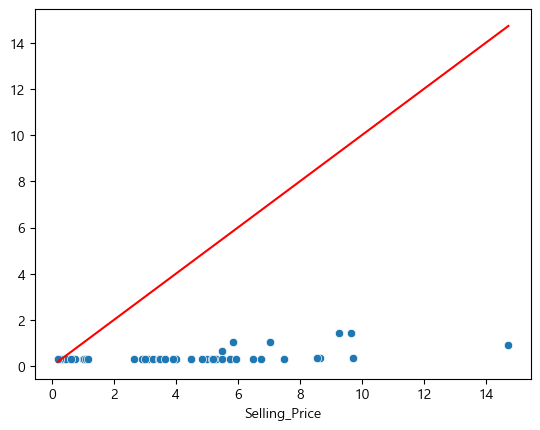

In [100]:
sns.scatterplot(x=y_test, y=y_pred1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")

plt.show()

In [101]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error

rmse = root_mean_squared_error (y_test, y_pred1)
print(f"RMSE: {rmse}")

RMSE: 4.459353529190648


## 선형모델

In [102]:
from sklearn.linear_model import LinearRegression

In [103]:
lr = LinearRegression()

In [104]:
lr.fit(X_train, y_train)

LinearRegression()

In [105]:
y_pred2 = lr.predict(X_test_scaled)

C:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [106]:
print(y_pred2)

[ 7.27901682 11.96590871  3.55446081 12.85183373  3.76084505  3.5063485
  3.21891324  7.15081114  7.27980071  7.00373946  7.51866853  3.50436071
  3.70315383 11.7511477   7.20675125  7.71576868  6.9101321   7.55287084
  7.67092949  3.86602956  7.39616359  3.32709107 13.22231642  6.26850958
  3.62810843  3.73477291 12.99772562 11.84138752  3.81791021  3.7232046
  3.9692355   7.37506872  3.72923719  7.4603168   3.78241161 13.35727135
  7.61255624  6.87326419  7.08598764 11.59946942  3.42727633  7.28478239
 12.64544481  7.07852687  7.22681193  7.67371316  3.93409801  7.23681017
 13.41580002  3.86047526  6.82654438 12.86695914  3.83043584 13.07551716
 12.72777071  3.00436568  3.83041471  7.6709344  13.07553175]


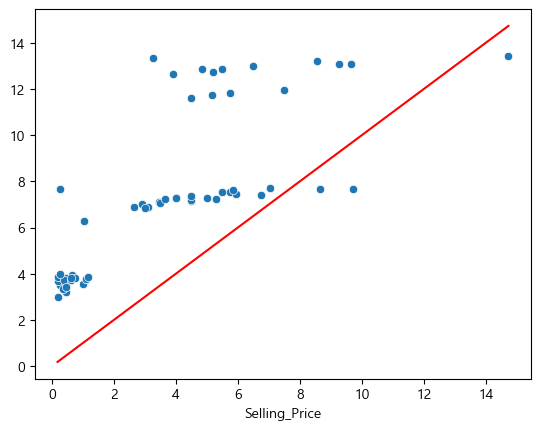

In [107]:
sns.scatterplot(x=y_test, y=y_pred2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")

plt.show()

In [108]:
rmse2 = root_mean_squared_error(y_test, y_pred2)
print(f"결정트리 RMSE: {rmse}")
print(f"선형모델 RMSE: {rmse2}")

결정트리 RMSE: 4.459353529190648
선형모델 RMSE: 4.235270142768873


In [109]:
"""
    결정트리 RMSE: 1.1793764511636315
    선형모델 RMSE: 1.1073053305563638
"""

None

In [110]:
# 규제
dtr = DecisionTreeRegressor(max_depth=60, min_samples_leaf=40)

In [111]:
dtr = dtr.fit(X_train_scaled, y_train)

In [112]:
y_pred3 = dtr.predict(X_test_scaled)

In [113]:
rmse3 = root_mean_squared_error(y_test, y_pred3)

print(f"규제 적용(가지치기) RMSE: {rmse3}")

규제 적용(가지치기) RMSE: 2.0986541062585533


In [114]:
from sklearn.tree import plot_tree

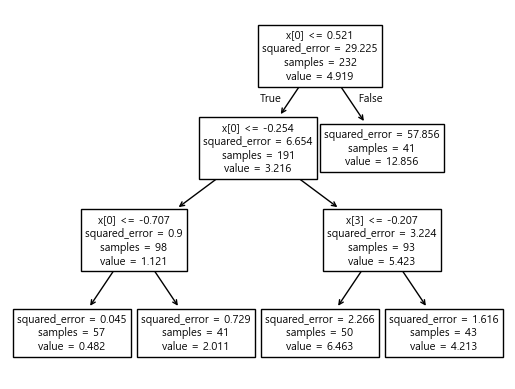

In [115]:
plot_tree(dtr)
plt.show()

# 랜덤 포레스트(RandomForestRegressor)
- "나무(결정 트리) 한 개는 과적합되기 쉬우니, 서로 다른 나무 100개를 만들어 그들의 예측값을 평균 내자!"
- 즉 결정트리의 상위 버전

## 핵심 하이퍼파라미터
* `n_estimators`: 숲에 심을 **나무의 개수** (기본값 100개, 많을수록 좋지만 무거워짐)
* `max_depth`, `min_samples_split` 등: 기존 결정 트리의 규제 파라미터와 완전히 동일하게 나무 각각에 적용됨

In [116]:
from sklearn.ensemble import RandomForestRegressor

In [117]:
rf = RandomForestRegressor (random_state=2026)

In [118]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=2026)

In [119]:
rf.score(X_test, y_test)

0.9422364350491657

In [137]:
y_pred4 = rf.predict(X_test)
y_pred4

array([ 5.5327,  7.1241,  1.076 ,  5.1795,  1.1605,  0.2956,  0.496 ,
        4.6847,  4.384 ,  2.7245,  6.867 ,  0.2897,  0.3552,  4.2895,
        4.9295,  7.282 ,  2.9095,  5.6505,  9.0106,  0.1736,  6.555 ,
        0.5194, 11.1655,  2.3   ,  0.5898,  0.612 ,  6.6515,  4.9265,
        0.4345,  0.4286,  0.2181,  5.341 ,  0.5641,  7.542 ,  1.189 ,
        2.5325,  6.568 ,  2.929 ,  4.449 ,  4.561 ,  0.5321,  4.253 ,
        4.194 ,  4.791 ,  5.012 ,  0.2121,  0.6853,  4.112 , 11.8691,
        1.125 ,  2.6565,  5.634 ,  0.6565,  7.9169,  4.989 ,  0.3631,
        0.6236,  9.5456,  7.8959])

In [138]:
rmse = root_mean_squared_error(y_pred4, y_test)
print(f"랜덤 포레스트 RMSE: {rmse}")

랜덤 포레스트 RMSE: 0.7564453372882176


In [139]:
rf.feature_importances

AttributeError: 'RandomForestRegressor' object has no attribute 'feature_importances'

In [140]:
featrues_imp = pd. DataFrame({
"Features": X_train. columns,
"importances": rf. feature_importances_
}).sort)valuses(by = "importances", acscending-False

featrues _imp

SyntaxError: unmatched ')' (1876953064.py, line 4)

In [142]:
sns.barplot(featrues_8mp, x="Features", y="importances", hue="Features")
plt.show

NameError: name 'featrues_8mp' is not defined